# dl-finance-ts-forecasting

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

## Step 1 (Data + Stationarity + Fractional Differencing)

In [45]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from scipy.stats import skew, kurtosis

Download market data

In [46]:
df_raw = yf.download(TICKER, period="max", interval=INTERVAL, auto_adjust=True, progress=False)

close = df_raw["Close"].dropna()

# If "Close" is a 1-column DataFrame, squeeze to Series
if isinstance(close, pd.DataFrame):
    if close.shape[1] == 1:
        close = close.iloc[:, 0]
    elif TICKER in close.columns:
        close = close[TICKER]
    else:
        # fallback: take first column
        close = close.iloc[:, 0]

price = close.iloc[-MAX_OBS:].copy()
price.name = f"{TICKER}_Close_Level"

Helper functions (summary stats + stationarity tests)

In [47]:
def summary_stats(series: pd.Series) -> pd.DataFrame:
    s = series.dropna()
    out = {
        "count": s.shape[0],
        "mean": s.mean(),
        "std": s.std(ddof=1),
        "min": s.min(),
        "25%": s.quantile(0.25),
        "50% (median)": s.median(),
        "75%": s.quantile(0.75),
        "max": s.max(),
        "skewness": skew(s.values),
        "excess_kurtosis": kurtosis(s.values, fisher=True),
    }
    return pd.DataFrame(out, index=[series.name if series.name else "series"]).T

def adf_test(series: pd.Series, autolag="AIC") -> dict:
    s = series.dropna()
    stat, pvalue, lags, nobs, crit, icbest = adfuller(s.values, autolag=autolag)
    return {
        "ADF Statistic": stat,
        "p-value": pvalue,
        "Used lags": lags,
        "N obs": nobs,
        "Critical 1%": crit["1%"],
        "Critical 5%": crit["5%"],
        "Critical 10%": crit["10%"],
        "IC Best": icbest,
    }

def kpss_test(series: pd.Series, regression="c", nlags="auto") -> dict:
    # KPSS null: stationary (level stationary if regression="c")
    s = series.dropna()
    stat, pvalue, lags, crit = kpss(s.values, regression=regression, nlags=nlags)
    return {
        "KPSS Statistic": stat,
        "p-value": pvalue,
        "Used lags": lags,
        "Critical 10%": crit["10%"],
        "Critical 5%": crit["5%"],
        "Critical 2.5%": crit["2.5%"],
        "Critical 1%": crit["1%"],
    }

def plot_series(series: pd.Series, title: str):
    plt.figure(figsize=(12, 4))
    plt.plot(series.index, series.values)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(series.name if series.name else "Value")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_hist(series: pd.Series, title: str, bins=60):
    plt.figure(figsize=(8, 4))
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.xlabel(series.name if series.name else "Value")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_acf_pacf(series: pd.Series, nlags=40, title_prefix=""):
    s = series.dropna()
    ac = acf(s, nlags=nlags, fft=True)
    pc = pacf(s, nlags=nlags, method="ywm")

    plt.figure(figsize=(12, 4))
    plt.stem(range(len(ac)), ac, basefmt=" ")
    plt.title(f"{title_prefix} ACF (0..{nlags})")
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.stem(range(len(pc)), pc, basefmt=" ")
    plt.title(f"{title_prefix} PACF (0..{nlags})")
    plt.xlabel("Lag")
    plt.ylabel("PACF")
    plt.grid(True, alpha=0.3)
    plt.show()

### STEP 1(a): Analyze levels

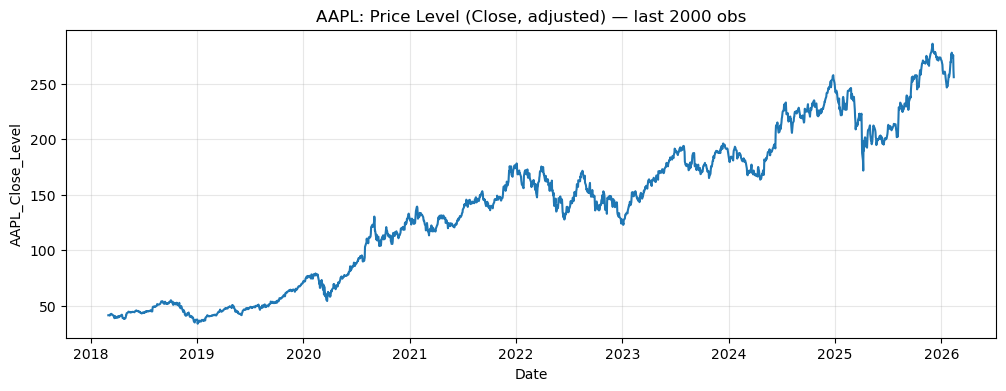

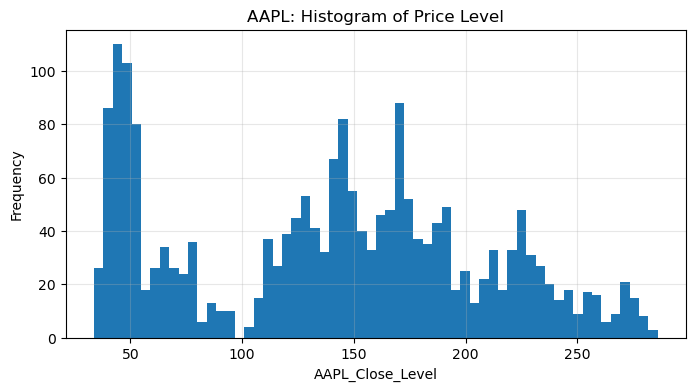

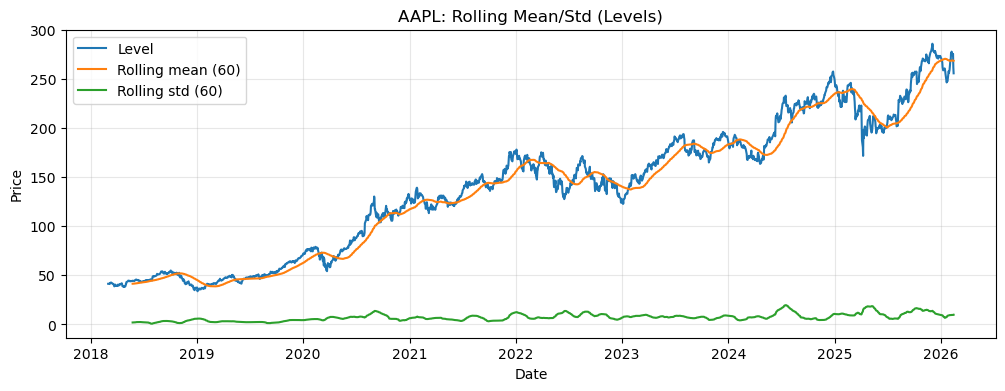

,AAPL_Close_Level
count,2000.000000
mean,139.241715
std,67.237127
min,33.768074
25%,69.854755
50% (median),144.831322
75%,187.142540
max,285.922455
skewness,0.040600
excess_kurtosis,-1.011771


,ADF Statistic,p-value,Used lags,N obs,Critical 1%,Critical 5%,Critical 10%,IC Best
ADF_levels,-0.465991,0.898484,10,1989,-3.433642,-2.862994,-2.567544,9518.427684


,KPSS Statistic,p-value,Used lags,Critical 10%,Critical 5%,Critical 2.5%,Critical 1%
KPSS_levels,6.577362,0.01,28,0.347,0.463,0.574,0.739


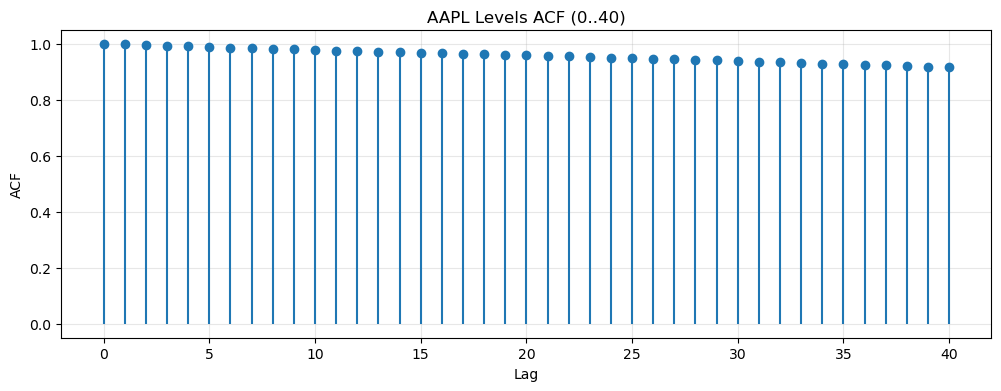

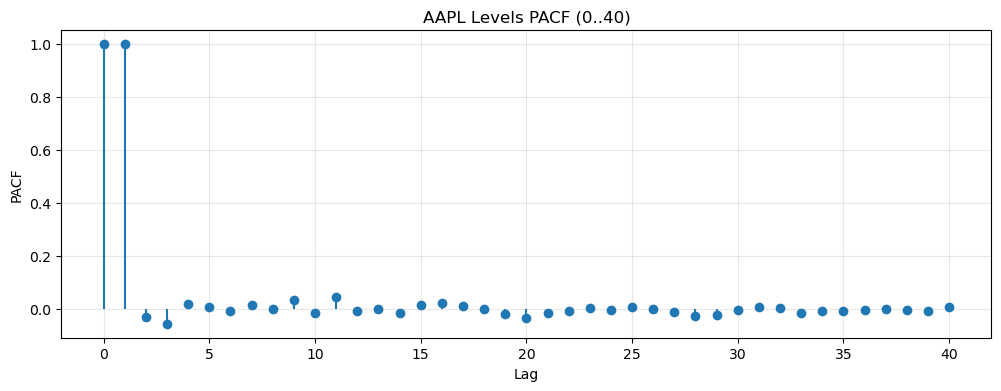

In [48]:
price.name = f"{TICKER}_Close_Level"

# Visualizations
plot_series(price, f"{TICKER}: Price Level (Close, adjusted) — last {len(price)} obs")
plot_hist(price, f"{TICKER}: Histogram of Price Level")

# Rolling mean/variance to visually assess non-stationarity
roll_window = min(60, max(20, len(price)//20))
rolling_mean = price.rolling(roll_window).mean()
rolling_std = price.rolling(roll_window).std()

plt.figure(figsize=(12,4))
plt.plot(price.index, price.values, label="Level")
plt.plot(rolling_mean.index, rolling_mean.values, label=f"Rolling mean ({roll_window})")
plt.plot(rolling_std.index, rolling_std.values, label=f"Rolling std ({roll_window})")
plt.title(f"{TICKER}: Rolling Mean/Std (Levels)")
plt.xlabel("Date"); plt.ylabel("Price")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

# Summary stats
display(summary_stats(price))

# Stationarity tests (levels)
adf_levels = adf_test(price)
kpss_levels = kpss_test(price, regression="c")
display(pd.DataFrame([adf_levels], index=["ADF_levels"]))
display(pd.DataFrame([kpss_levels], index=["KPSS_levels"]))

# Persistence (ACF/PACF)
plot_acf_pacf(price, nlags=40, title_prefix=f"{TICKER} Levels")

### STEP 1(b): Create a stationary transform (log returns)

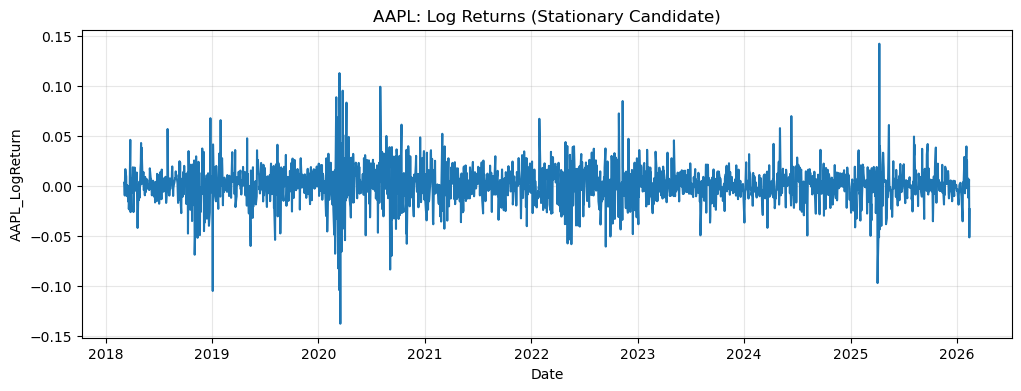

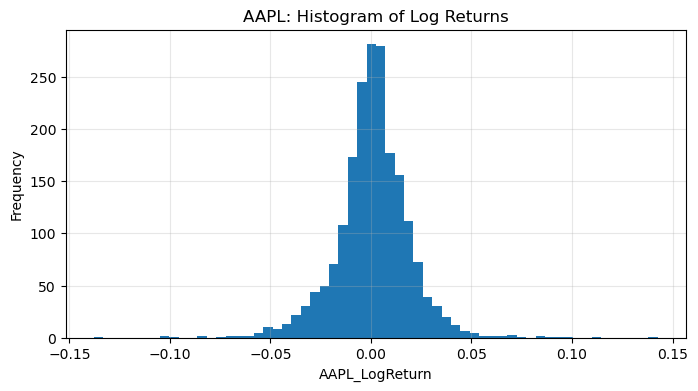

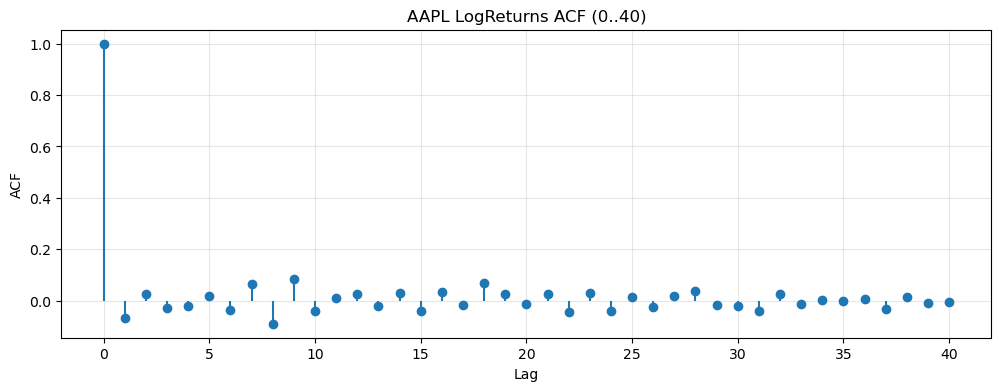

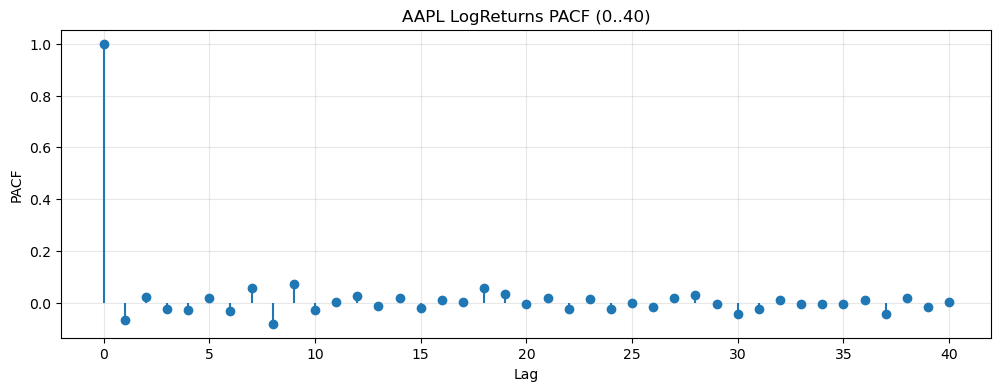

,AAPL_LogReturn
count,1999.000000
mean,0.000911
std,0.019394
min,-0.137708
25%,-0.007957
50% (median),0.001186
75%,0.010874
max,0.142617
skewness,-0.087685
excess_kurtosis,6.219094


,ADF Statistic,p-value,Used lags,N obs,Critical 1%,Critical 5%,Critical 10%,IC Best
ADF_log_returns,-14.659396,3.400420e-27,8,1990,-3.43364,-2.862993,-2.567544,-9971.602753


,KPSS Statistic,p-value,Used lags,Critical 10%,Critical 5%,Critical 2.5%,Critical 1%
KPSS_log_returns,0.094812,0.1,5,0.347,0.463,0.574,0.739


In [49]:
# Stationary transform: log returns
log_price = np.log(price)
log_ret = log_price.diff().dropna()
log_ret.name = f"{TICKER}_LogReturn"

plot_series(log_ret, f"{TICKER}: Log Returns (Stationary Candidate)")
plot_hist(log_ret, f"{TICKER}: Histogram of Log Returns")
plot_acf_pacf(log_ret, nlags=40, title_prefix=f"{TICKER} LogReturns")

display(summary_stats(log_ret))

adf_ret = adf_test(log_ret)
kpss_ret = kpss_test(log_ret, regression="c")
display(pd.DataFrame([adf_ret], index=["ADF_log_returns"]))
display(pd.DataFrame([kpss_ret], index=["KPSS_log_returns"]))

### STEP 1(c): Fractional differencing (fixed-width method)

In [50]:
THRESH = 1e-3         
MIN_FD_OBS = 1000     

d_grid = np.round(np.arange(0.0, 1.01, 0.05), 2)

results = []
for d in d_grid:
    if d == 0.0:
        fd = price.copy()
        fd.name = f"{price.name}_d=0.00"
    else:
        fd = fracdiff_fixed_width(price, d=d, thresh=THRESH)

    if len(fd) < 50:
        continue

    adf = adf_test(fd)
    kp  = kpss_test(fd, regression="c")     # keep as diagnostic
    c   = corr_overlap(price, fd)

    results.append([d, len(fd), adf["p-value"], kp["p-value"], adf["ADF Statistic"], c])

res_df = pd.DataFrame(
    results,
    columns=["d", "n_obs_fd", "adf_pvalue", "kpss_pvalue", "adf_stat", "corr_with_level"]
)

display(res_df)

# ---- Selection rule (IMPORTANT):
# 1) Stationary by ADF
# 2) Enough observations for ML
# 3) Prefer smaller d (more memory)
stationary = res_df[(res_df["adf_pvalue"] < 0.05) & (res_df["n_obs_fd"] >= MIN_FD_OBS)].copy()

if stationary.empty:
    # fallback: pick best ADF, then most observations, then highest corr
    best_d = res_df.sort_values(
        ["adf_pvalue", "n_obs_fd", "corr_with_level"],
        ascending=[True, False, False]
    ).iloc[0]["d"]
else:
    best_d = stationary.sort_values(["d", "corr_with_level"], ascending=[True, False]).iloc[0]["d"]

# Enforce fractional d if possible (avoid d=1.00 unless nothing else works)
if best_d == 1.0:
    frac_candidates = stationary[stationary["d"] < 1.0].copy()
    if not frac_candidates.empty:
        best_d = frac_candidates.sort_values(["d", "corr_with_level"], ascending=[True, False]).iloc[0]["d"]

print("Selected d:", best_d)

fd_series = fracdiff_fixed_width(price, d=float(best_d), thresh=THRESH)
fd_series.name = f"{TICKER}_FracDiff_d={best_d:.2f}"

adf_fd = adf_test(fd_series)
kpss_fd = kpss_test(fd_series, regression="c")

print("FracDiff obs:", len(fd_series))
print("ADF p-value:", adf_fd["p-value"])
print("KPSS p-value:", kpss_fd["p-value"])
print("Corr with level:", corr_overlap(price, fd_series))


,d,n_obs_fd,adf_pvalue,kpss_pvalue,adf_stat,corr_with_level
0,0.00,2000,8.984841e-01,0.01,-0.465991,1.000000
1,0.05,1960,8.700379e-01,0.01,-0.604166,0.999842
2,0.10,1939,8.147288e-01,0.01,-0.814824,0.998867
3,0.15,1929,7.271550e-01,0.01,-1.069308,0.996487
4,0.20,1928,6.303143e-01,0.01,-1.297502,0.992406
5,0.25,1930,6.621647e-01,0.01,-1.226337,0.985981
6,0.30,1935,5.792132e-01,0.01,-1.406381,0.976921
7,0.35,1940,4.839071e-01,0.01,-1.599376,0.963880
8,0.40,1946,3.870765e-01,0.01,-1.786716,0.946538
9,0.45,1952,2.872207e-01,0.01,-1.998524,0.923512


Selected d: 0.6
FracDiff obs: 1967
ADF p-value: 0.04796196291375174
KPSS p-value: 0.01
Corr with level: 0.8022935739716165


### STEP 1(d): Package outputs for later report + quick comparison table

In [51]:
# Build a clean comparison table (core diagnostics)
comparison = pd.DataFrame({
    "Series": ["Levels", "Log Returns", f"FracDiff(d={best_d:.2f})"],
    "n_obs": [len(price), len(log_ret), len(fd_series)],
    "ADF p-value": [adf_levels["p-value"], adf_ret["p-value"], adf_fd["p-value"]],
    "KPSS p-value": [kpss_levels["p-value"], kpss_ret["p-value"], kpss_fd["p-value"]],
    "Mean": [price.mean(), log_ret.mean(), fd_series.mean()],
    "Std": [price.std(ddof=1), log_ret.std(ddof=1), fd_series.std(ddof=1)],
    "Skew": [skew(price.dropna()), skew(log_ret.dropna()), skew(fd_series.dropna())],
    "Excess Kurtosis": [kurtosis(price.dropna(), fisher=True),
                        kurtosis(log_ret.dropna(), fisher=True),
                        kurtosis(fd_series.dropna(), fisher=True)],
})

display(comparison)

# Save series (so Step 2 can reuse cleanly)
step1_data = pd.concat([price, log_ret, fd_series], axis=1)
step1_data.to_csv(f"step1_{TICKER}_{INTERVAL}_data.csv")
print("Saved:", f"step1_{TICKER}_{INTERVAL}_data.csv")

,Series,n_obs,ADF p-value,KPSS p-value,Mean,Std,Skew,Excess Kurtosis
0,Levels,2000,8.984841e-01,0.01,139.241715,67.237127,0.040600,-1.011771
1,Log Returns,1999,3.400420e-27,0.10,0.000911,0.019394,-0.087685,6.219094
2,FracDiff(d=0.60),1967,4.796196e-02,0.01,8.074116,4.818537,0.414130,0.085311


Saved: step1_AAPL_1d_data.csv


In [52]:
type(price), getattr(price, "shape", None)

(pandas.core.series.Series, (2000,))

In [53]:
display(summary_stats(price))

,AAPL_Close_Level
count,2000.000000
mean,139.241715
std,67.237127
min,33.768074
25%,69.854755
50% (median),144.831322
75%,187.142540
max,285.922455
skewness,0.040600
excess_kurtosis,-1.011771


## Step 2 (MLP on all 3 representations)

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# Load the Step 1 saved file
step1_path = f"step1_{TICKER}_{INTERVAL}_data.csv"
df = pd.read_csv(step1_path, index_col=0, parse_dates=True)

df.columns

Index(['AAPL_Close_Level', 'AAPL_LogReturn', 'AAPL_FracDiff_d=0.60'], dtype='object')

In [56]:
level_col = [c for c in df.columns if "Close_Level" in c][0]
ret_col   = [c for c in df.columns if "LogReturn" in c][0]
fd_col    = [c for c in df.columns if "FracDiff" in c][0]

y_level = df[level_col].dropna().copy()
y_ret   = df[ret_col].dropna().copy()
y_fd    = df[fd_col].dropna().copy()

print("Level:", level_col, y_level.shape)
print("Return:", ret_col, y_ret.shape)
print("FracDiff:", fd_col, y_fd.shape)

Level: AAPL_Close_Level (2000,)
Return: AAPL_LogReturn (1999,)
FracDiff: AAPL_FracDiff_d=0.60 (1967,)


Helper functions (lags, split, model, evaluation)

In [57]:
def make_lagged_df(series: pd.Series, n_lags: int) -> pd.DataFrame:
    """
    Creates supervised learning dataset:
    X_t = [y_{t-1}, ..., y_{t-n_lags}], target y_t
    """
    s = series.dropna().copy()
    data = {}
    for lag in range(1, n_lags + 1):
        data[f"lag_{lag}"] = s.shift(lag)
    data["y"] = s
    out = pd.DataFrame(data, index=s.index).dropna()
    return out

def time_split(df_supervised: pd.DataFrame, train_frac=0.70, val_frac=0.15):
    """
    Splits in time order: Train -> Val -> Test
    """
    n = len(df_supervised)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train = df_supervised.iloc[:n_train].copy()
    val   = df_supervised.iloc[n_train:n_train+n_val].copy()
    test  = df_supervised.iloc[n_train+n_val:].copy()

    return train, val, test

def build_mlp(input_dim: int, hidden=(64, 32), dropout=0.1, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for h in hidden:
        model.add(layers.Dense(h, activation="relu"))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="linear"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse"
    )
    return model

def evaluate_regression(y_true, y_pred) -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

def plot_predictions(index, y_true, y_pred, title):
    plt.figure(figsize=(12,4))
    plt.plot(index, y_true, label="Actual")
    plt.plot(index, y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Train one MLP (generic runner)

In [58]:
def run_mlp_experiment(series: pd.Series, n_lags=20, train_frac=0.70, val_frac=0.15,
                       hidden=(64,32), dropout=0.1, lr=1e-3, batch_size=32, epochs=200,
                       patience=20, verbose=0, seed=42):
    tf.keras.utils.set_random_seed(seed)

    sup = make_lagged_df(series, n_lags=n_lags)
    train, val, test = time_split(sup, train_frac=train_frac, val_frac=val_frac)

    X_train, y_train = train.drop(columns=["y"]).values, train["y"].values
    X_val, y_val     = val.drop(columns=["y"]).values, val["y"].values
    X_test, y_test   = test.drop(columns=["y"]).values, test["y"].values

    # Scale features ONLY using train
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    model = build_mlp(input_dim=X_train_s.shape[1], hidden=hidden, dropout=dropout, lr=lr)

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    ]

    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    # Predictions
    yhat_train = model.predict(X_train_s).ravel()
    yhat_val   = model.predict(X_val_s).ravel()
    yhat_test  = model.predict(X_test_s).ravel()

    metrics = {
        "train": evaluate_regression(y_train, yhat_train),
        "val":   evaluate_regression(y_val,   yhat_val),
        "test":  evaluate_regression(y_test,  yhat_test),
    }

    out = {
        "series_name": series.name,
        "n_lags": n_lags,
        "supervised": sup,
        "splits": (train, val, test),
        "scaler": scaler,
        "model": model,
        "history": history.history,
        "pred": {
            "train": (train.index, y_train, yhat_train),
            "val":   (val.index,   y_val,   yhat_val),
            "test":  (test.index,  y_test,  yhat_test),
        },
        "metrics": metrics
    }
    return out

### Step 2(a): Levels → predict Levels

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


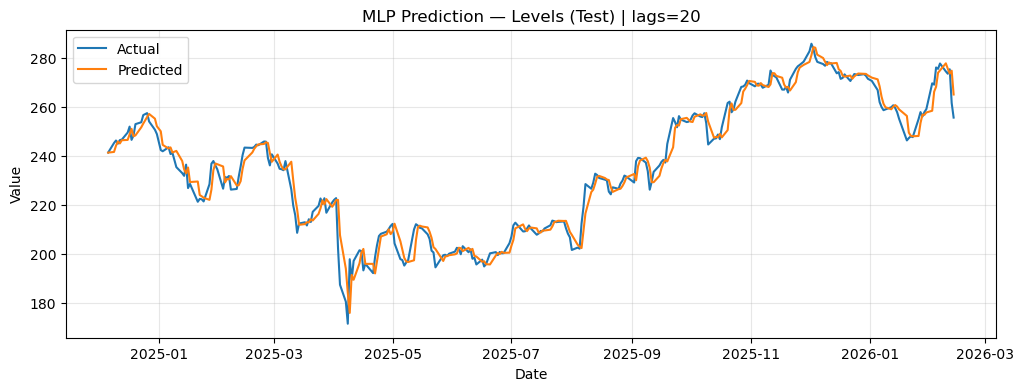

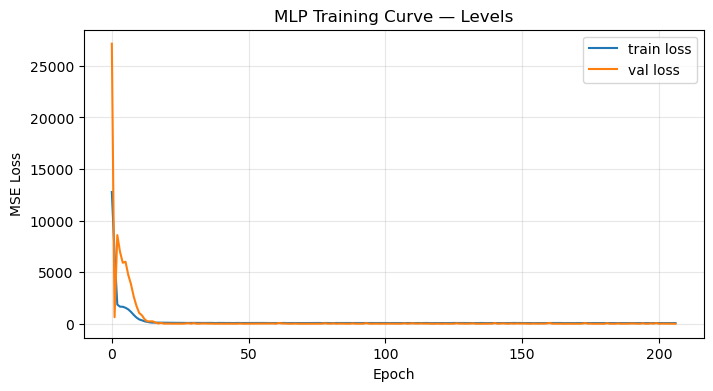

In [60]:
exp_level = run_mlp_experiment(
    y_level, n_lags=20,
    hidden=(128,64), dropout=0.1, lr=1e-3,
    epochs=300, patience=30, verbose=0
)

exp_level["metrics"]

idx, yt, yp = exp_level["pred"]["test"]
plot_predictions(idx, yt, yp, f"MLP Prediction — Levels (Test) | lags={exp_level['n_lags']}")

plt.figure(figsize=(8,4))
plt.plot(exp_level["history"]["loss"], label="train loss")
plt.plot(exp_level["history"]["val_loss"], label="val loss")
plt.title("MLP Training Curve — Levels")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

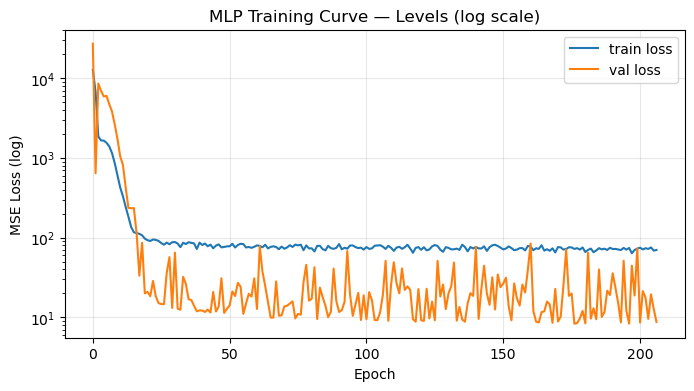

In [64]:
plt.figure(figsize=(8,4))
plt.plot(exp_level["history"]["loss"], label="train loss")
plt.plot(exp_level["history"]["val_loss"], label="val loss")
plt.yscale("log")
plt.title("MLP Training Curve — Levels (log scale)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Step 2(b): Log Returns → predict Log Returns

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


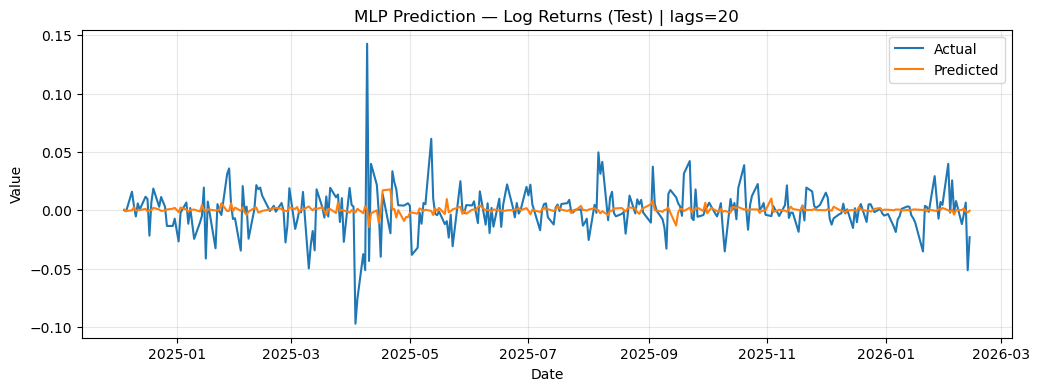

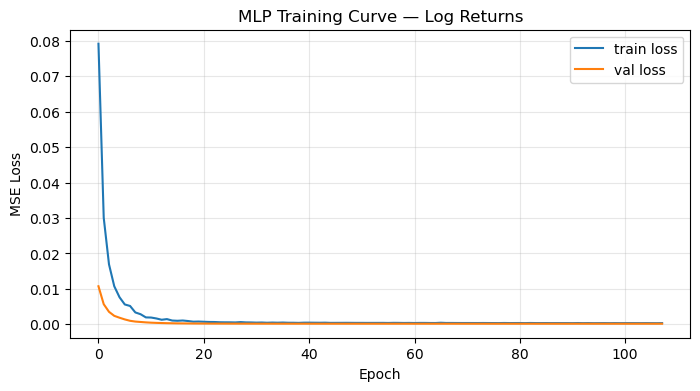

In [61]:
exp_ret = run_mlp_experiment(
    y_ret, n_lags=20,
    hidden=(64,32), dropout=0.1, lr=1e-3,
    epochs=300, patience=30, verbose=0
)

exp_ret["metrics"]

idx, yt, yp = exp_ret["pred"]["test"]
plot_predictions(idx, yt, yp, f"MLP Prediction — Log Returns (Test) | lags={exp_ret['n_lags']}")

plt.figure(figsize=(8,4))
plt.plot(exp_ret["history"]["loss"], label="train loss")
plt.plot(exp_ret["history"]["val_loss"], label="val loss")
plt.title("MLP Training Curve — Log Returns")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


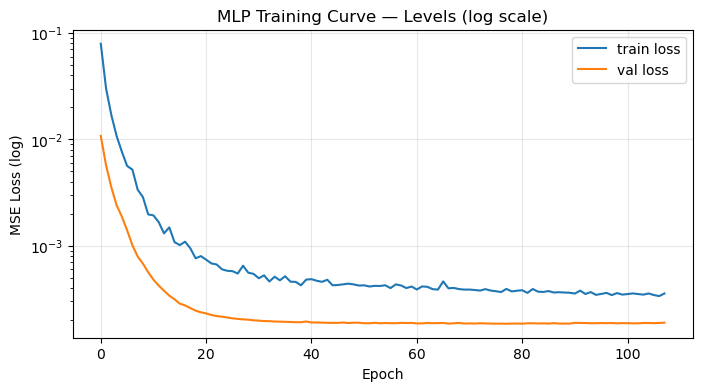

In [65]:
plt.figure(figsize=(8,4))
plt.plot(exp_ret["history"]["loss"], label="train loss")
plt.plot(exp_ret["history"]["val_loss"], label="val loss")
plt.yscale("log")
plt.title("MLP Training Curve — Levels (log scale)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Step 2(c): FracDiff → predict FracDiff

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


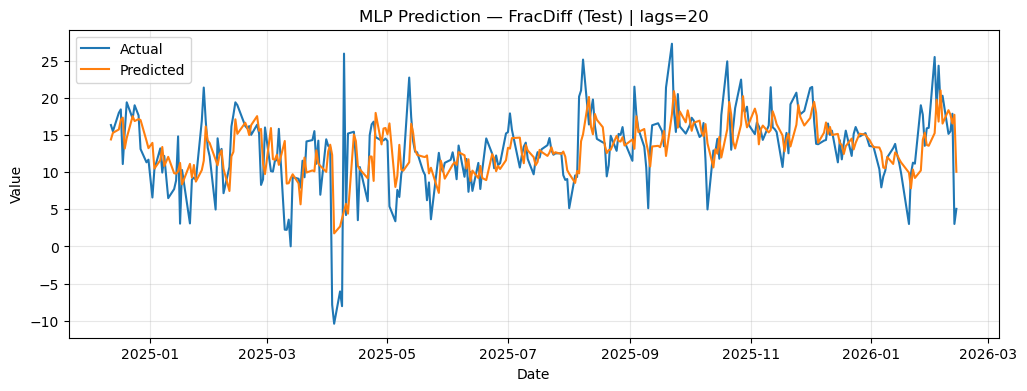

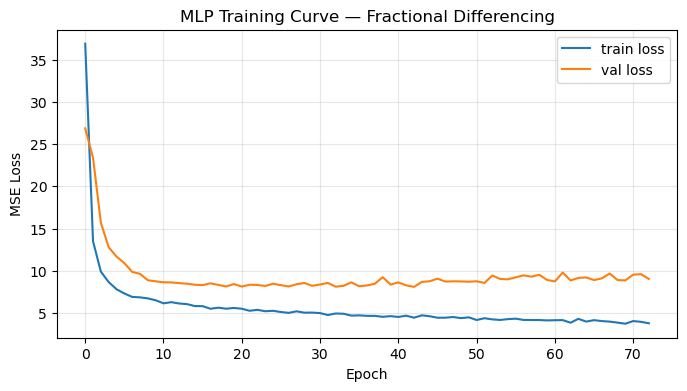

In [62]:
exp_fd = run_mlp_experiment(
    y_fd, n_lags=20,
    hidden=(64,32), dropout=0.1, lr=1e-3,
    epochs=300, patience=30, verbose=0
)

exp_fd["metrics"]

idx, yt, yp = exp_fd["pred"]["test"]
plot_predictions(idx, yt, yp, f"MLP Prediction — FracDiff (Test) | lags={exp_fd['n_lags']}")

plt.figure(figsize=(8,4))
plt.plot(exp_fd["history"]["loss"], label="train loss")
plt.plot(exp_fd["history"]["val_loss"], label="val loss")
plt.title("MLP Training Curve — Fractional Differencing")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


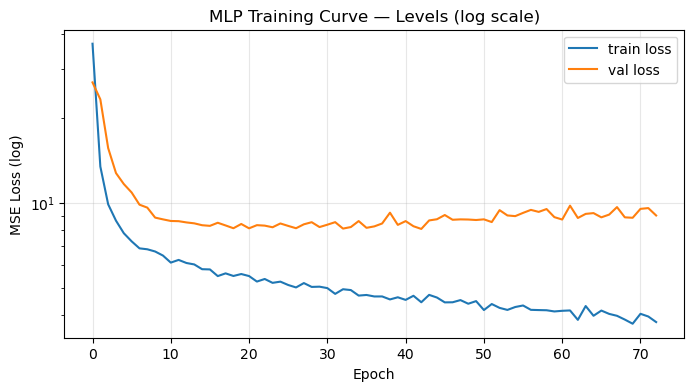

In [66]:
plt.figure(figsize=(8,4))
plt.plot(exp_fd["history"]["loss"], label="train loss")
plt.plot(exp_fd["history"]["val_loss"], label="val loss")
plt.yscale("log")
plt.title("MLP Training Curve — Levels (log scale)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Step 2(d): Compare all 3 models (table + bar plot)

,Series,Test_RMSE,Test_MAE,Test_R2,Lags
0,Levels,4.608993,3.151834,0.969547,20
1,Log Returns,0.019589,0.012703,-0.008393,20
2,FracDiff,4.313918,2.994674,0.298741,20


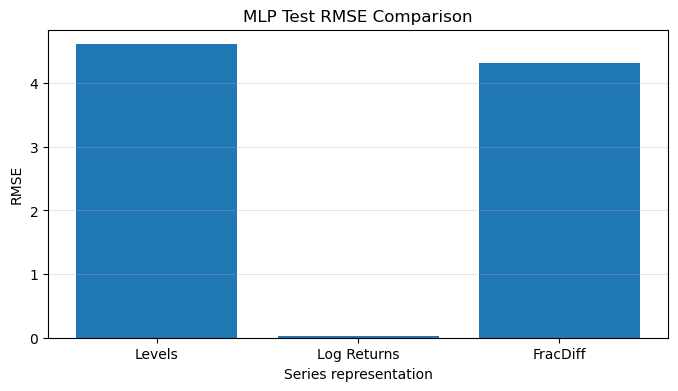

Saved: step2_mlp_results.csv


In [63]:
def metrics_row(name, exp):
    return {
        "Series": name,
        "Test_RMSE": exp["metrics"]["test"]["RMSE"],
        "Test_MAE": exp["metrics"]["test"]["MAE"],
        "Test_R2": exp["metrics"]["test"]["R2"],
        "Lags": exp["n_lags"]
    }

mlp_compare = pd.DataFrame([
    metrics_row("Levels", exp_level),
    metrics_row("Log Returns", exp_ret),
    metrics_row("FracDiff", exp_fd)
])

display(mlp_compare)

plt.figure(figsize=(8,4))
plt.bar(mlp_compare["Series"], mlp_compare["Test_RMSE"])
plt.title("MLP Test RMSE Comparison")
plt.xlabel("Series representation")
plt.ylabel("RMSE")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

mlp_compare.to_csv("step2_mlp_results.csv", index=False)
print("Saved: step2_mlp_results.csv")

## Step 3 (CNN with GAF images on all 3 representations)

In [68]:
from pyts.image import GramianAngularField

In [100]:
step1_path = f"step1_{TICKER}_{INTERVAL}_data.csv"
df = pd.read_csv(step1_path, index_col=0, parse_dates=True)

level_col = [c for c in df.columns if "Close_Level" in c][0]
ret_col   = [c for c in df.columns if "LogReturn" in c][0]
fd_col    = [c for c in df.columns if "FracDiff" in c][0]

y_level = df[level_col].dropna().copy()
y_ret   = df[ret_col].dropna().copy()
y_fd    = df[fd_col].dropna().copy()

print(level_col, y_level.shape)
print(ret_col, y_ret.shape)
print(fd_col, y_fd.shape)

AAPL_Close_Level (2000,)
AAPL_LogReturn (1999,)
AAPL_FracDiff_d=0.60 (1967,)


Helpers: make sliding windows + time split (no leakage)

In [101]:
def make_windowed_series(series: pd.Series, window_size: int):
    """
    Returns:
      X_windows: shape (n_samples, window_size)
      y_target : shape (n_samples,)
      idx      : datetime index aligned to targets
    """
    s = series.dropna()
    values = s.values
    idx = s.index

    X_list, y_list, t_idx = [], [], []
    for t in range(window_size, len(values)):
        X_list.append(values[t - window_size:t])  # past window_size values
        y_list.append(values[t])                  # predict current value
        t_idx.append(idx[t])

    return np.array(X_list), np.array(y_list), pd.DatetimeIndex(t_idx)

def time_split_arrays(X, y, idx, train_frac=0.70, val_frac=0.15):
    n = len(y)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)

    X_train, y_train, idx_train = X[:n_train], y[:n_train], idx[:n_train]
    X_val, y_val, idx_val       = X[n_train:n_train+n_val], y[n_train:n_train+n_val], idx[n_train:n_train+n_val]
    X_test, y_test, idx_test    = X[n_train+n_val:], y[n_train+n_val:], idx[n_train+n_val:]

    return (X_train, y_train, idx_train), (X_val, y_val, idx_val), (X_test, y_test, idx_test)

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

In [102]:
def scale_windows_to_minus1_1(X):
    """
    Scale each window (row) independently to [-1, 1].
    """
    X = X.astype(float)
    row_min = X.min(axis=1, keepdims=True)
    row_max = X.max(axis=1, keepdims=True)
    denom = (row_max - row_min)
    denom[denom == 0] = 1.0
    X01 = (X - row_min) / denom          # [0,1]
    X11 = 2 * X01 - 1                    # [-1,1]
    return X11

Convert windows → GAF images

In [103]:
def fit_gaf_transformer(X_train_windows, method="summation"):
    gaf = GramianAngularField(method=method)
    gaf.fit(X_train_windows)
    return gaf

CNN model builder

In [104]:
def build_cnn(input_shape, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="linear")
    ])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

In [105]:
def build_cnn_with_scalar(image_shape, lr=1e-3):
    img_in = keras.Input(shape=image_shape, name="gaf_image")

    x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(img_in)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)

    scalar_in = keras.Input(shape=(1,), name="last_value")
    s = layers.Dense(16, activation="relu")(scalar_in)

    z = layers.Concatenate()([x, s])
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(1, activation="linear")(z)

    model = keras.Model(inputs=[img_in, scalar_in], outputs=out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return model

Run one full GAF+CNN experiment (train/val/test)

In [106]:
def run_gaf_cnn_with_scalar(series: pd.Series,
                            window_size=32,
                            gaf_method="summation",
                            train_frac=0.70,
                            val_frac=0.15,
                            lr=1e-3,
                            batch_size=32,
                            epochs=120,
                            patience=15,
                            verbose=0,
                            seed=42):

    tf.keras.utils.set_random_seed(seed)

    Xw, y, idx = make_windowed_series(series, window_size=window_size)
    (Xw_tr, y_tr, idx_tr), (Xw_va, y_va, idx_va), (Xw_te, y_te, idx_te) = time_split_arrays(
        Xw, y, idx, train_frac=train_frac, val_frac=val_frac
    )

    # Scalar context feature: last observed value in the (raw) window
    last_tr = Xw_tr[:, -1].reshape(-1, 1)
    last_va = Xw_va[:, -1].reshape(-1, 1)
    last_te = Xw_te[:, -1].reshape(-1, 1)

    # Per-window scaling for GAF shape
    Xw_tr_s = scale_windows_to_minus1_1(Xw_tr)
    Xw_va_s = scale_windows_to_minus1_1(Xw_va)
    Xw_te_s = scale_windows_to_minus1_1(Xw_te)

    # Fit GAF on TRAIN only
    gaf = fit_gaf_transformer(Xw_tr_s, method=gaf_method)
    X_tr = gaf.transform(Xw_tr_s)[..., np.newaxis]
    X_va = gaf.transform(Xw_va_s)[..., np.newaxis]
    X_te = gaf.transform(Xw_te_s)[..., np.newaxis]

    # Scale target using TRAIN only
    y_scaler = StandardScaler()
    y_tr_s = y_scaler.fit_transform(y_tr.reshape(-1,1)).ravel()
    y_va_s = y_scaler.transform(y_va.reshape(-1,1)).ravel()
    y_te_s = y_scaler.transform(y_te.reshape(-1,1)).ravel()

    # Also scale scalar feature using TRAIN only (important)
    last_scaler = StandardScaler()
    last_tr_s = last_scaler.fit_transform(last_tr)
    last_va_s = last_scaler.transform(last_va)
    last_te_s = last_scaler.transform(last_te)

    model = build_cnn_with_scalar(image_shape=X_tr.shape[1:], lr=lr)

    callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)]

    history = model.fit(
        {"gaf_image": X_tr, "last_value": last_tr_s}, y_tr_s,
        validation_data=({"gaf_image": X_va, "last_value": last_va_s}, y_va_s),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        callbacks=callbacks
    )

    yhat_te_s = model.predict({"gaf_image": X_te, "last_value": last_te_s}, verbose=0).ravel()
    yhat_te = y_scaler.inverse_transform(yhat_te_s.reshape(-1,1)).ravel()

    metrics_test = regression_metrics(y_te, yhat_te)

    return {
        "series_name": series.name,
        "window_size": window_size,
        "gaf_method": gaf_method,
        "model": model,
        "history": history.history,
        "metrics_test": metrics_test,
        "pred_test": (idx_te, y_te, yhat_te),
        "sample_gaf": X_tr[0, :, :, 0],
    }


Visual helpers (sample GAF + predictions + loss)

In [107]:
def plot_gaf_image(img2d, title):
    plt.figure(figsize=(4,4))
    plt.imshow(img2d, aspect="auto")
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_pred(idx, y_true, y_pred, title):
    plt.figure(figsize=(12,4))
    plt.plot(idx, y_true, label="Actual")
    plt.plot(idx, y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def plot_loss(history, title):
    plt.figure(figsize=(8,4))
    plt.plot(history["loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss (scaled target)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

### Step 3(a) — Levels → GAF → CNN

{'RMSE': np.float64(8.82161560648282), 'MAE': 7.679759412198452, 'R2': 0.8887947061874264}


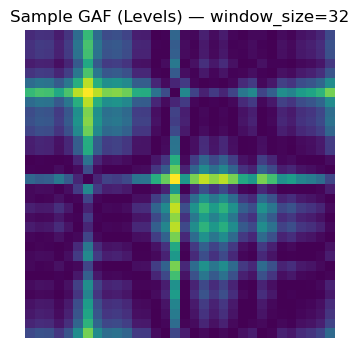

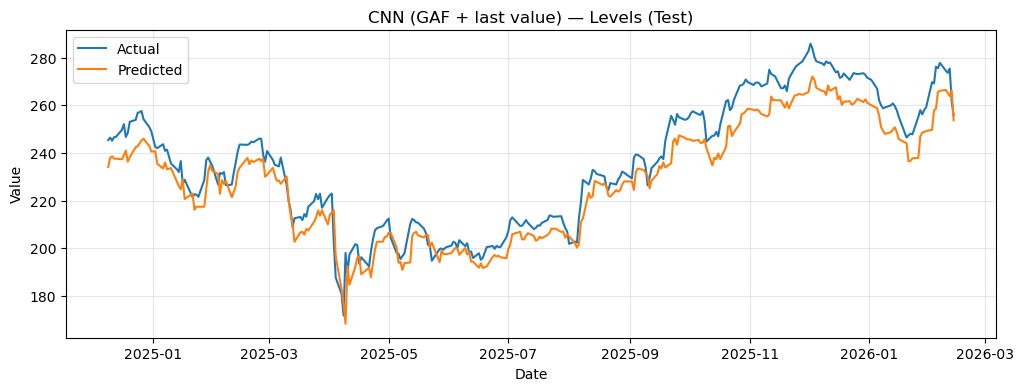

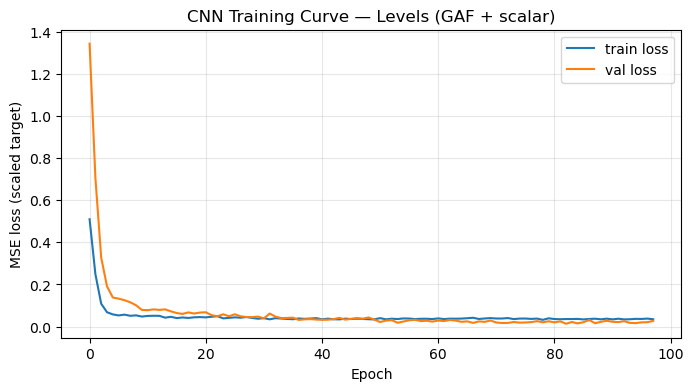

In [113]:
exp_cnn_level = run_gaf_cnn_with_scalar(
    y_level, window_size=32, gaf_method="summation",
    lr=1e-3, batch_size=32, epochs=120, patience=15, verbose=0
)

print(exp_cnn_level["metrics_test"])
plot_gaf_image(exp_cnn_level["sample_gaf"], "Sample GAF (Levels) — window_size=32")

idx, yt, yp = exp_cnn_level["pred_test"]
plot_pred(idx, yt, yp, "CNN (GAF + last value) — Levels (Test)")
plot_loss(exp_cnn_level["history"], "CNN Training Curve — Levels (GAF + scalar)")

### Step 3(b) — Log Returns → GAF → CNN

{'RMSE': np.float64(0.01963621365410532), 'MAE': 0.012486492944086042, 'R2': -0.006498847968566812}


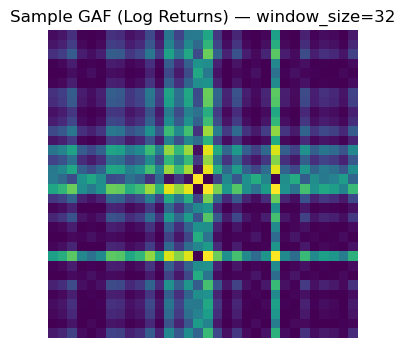

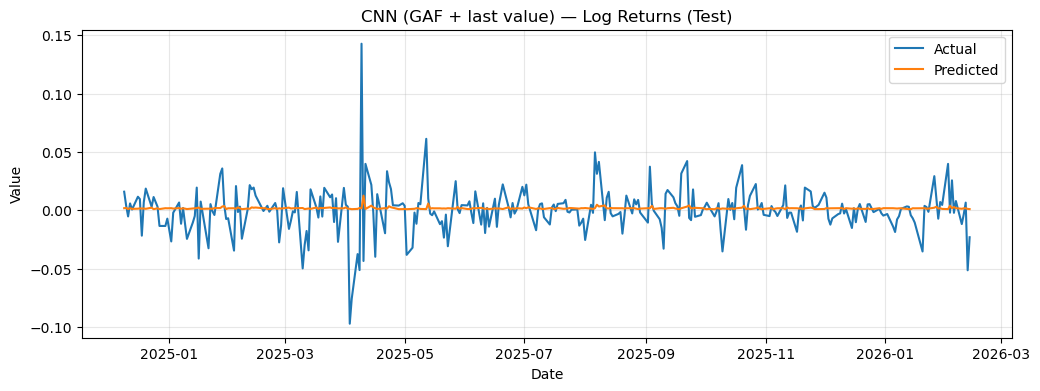

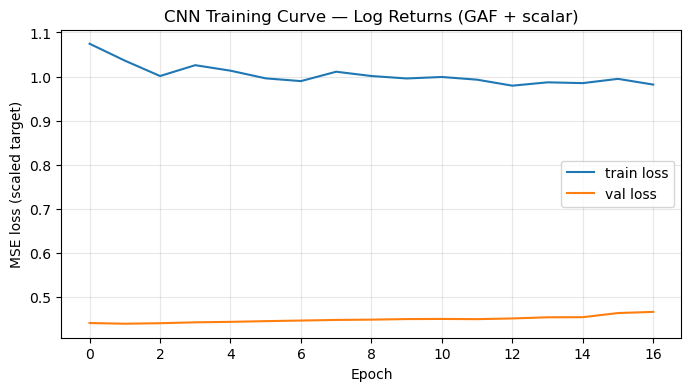

In [114]:
exp_cnn_ret = run_gaf_cnn_with_scalar(
    y_ret, window_size=32, gaf_method="summation",
    lr=1e-3, batch_size=32, epochs=120, patience=15, verbose=0
)

print(exp_cnn_ret["metrics_test"])
plot_gaf_image(exp_cnn_ret["sample_gaf"], "Sample GAF (Log Returns) — window_size=32")

idx, yt, yp = exp_cnn_ret["pred_test"]
plot_pred(idx, yt, yp, "CNN (GAF + last value) — Log Returns (Test)")
plot_loss(exp_cnn_ret["history"], "CNN Training Curve — Log Returns (GAF + scalar)")

### Step 3(c) — FracDiff → GAF → CNN

{'RMSE': np.float64(5.010786393096097), 'MAE': 3.812090010945413, 'R2': 0.058458743035575855}


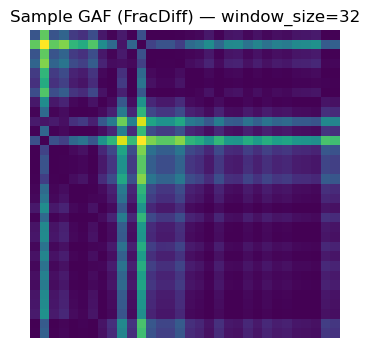

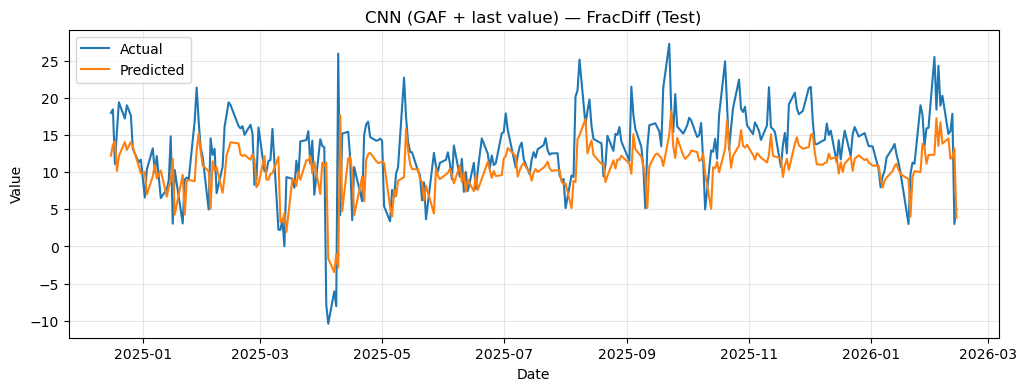

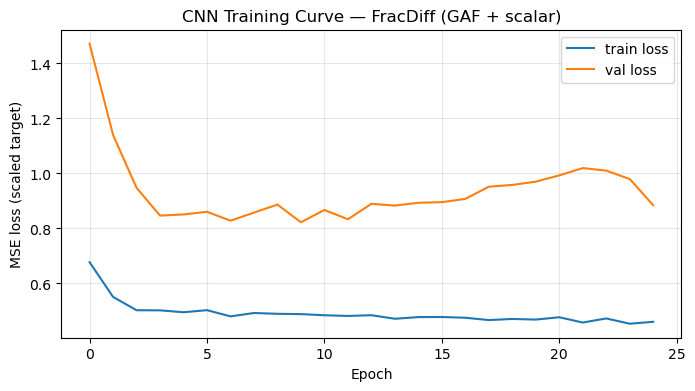

In [115]:
exp_cnn_fd = run_gaf_cnn_with_scalar(
    y_fd, window_size=32, gaf_method="summation",
    lr=1e-3, batch_size=32, epochs=120, patience=15, verbose=0
)

print(exp_cnn_fd["metrics_test"])
plot_gaf_image(exp_cnn_fd["sample_gaf"], "Sample GAF (FracDiff) — window_size=32")

idx, yt, yp = exp_cnn_fd["pred_test"]
plot_pred(idx, yt, yp, "CNN (GAF + last value) — FracDiff (Test)")
plot_loss(exp_cnn_fd["history"], "CNN Training Curve — FracDiff (GAF + scalar)")

### Step 3(d) — Compare the three CNNs (table + plot)

,Series,Window,Test_RMSE,Test_MAE,Test_R2,GAF_method
0,Levels,32,8.821616,7.679759,0.888795,summation
1,Log Returns,32,0.019636,0.012486,-0.006499,summation
2,FracDiff,32,5.010786,3.812090,0.058459,summation


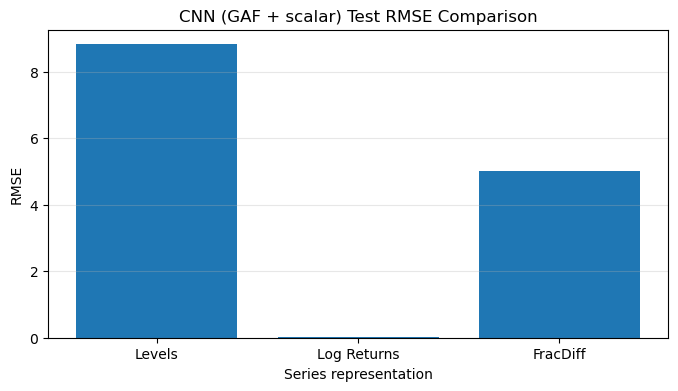

Saved: step3_cnn_gaf_scalar_results.csv


In [116]:
def row_scalar(name, exp):
    return {
        "Series": name,
        "Window": exp["window_size"],
        "Test_RMSE": exp["metrics_test"]["RMSE"],
        "Test_MAE": exp["metrics_test"]["MAE"],
        "Test_R2": exp["metrics_test"]["R2"],
        "GAF_method": exp["gaf_method"]
    }

cnn_compare = pd.DataFrame([
    row_scalar("Levels", exp_cnn_level),
    row_scalar("Log Returns", exp_cnn_ret),
    row_scalar("FracDiff", exp_cnn_fd),
])

display(cnn_compare)

plt.figure(figsize=(8,4))
plt.bar(cnn_compare["Series"], cnn_compare["Test_RMSE"])
plt.title("CNN (GAF + scalar) Test RMSE Comparison")
plt.xlabel("Series representation")
plt.ylabel("RMSE")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

cnn_compare.to_csv("step3_cnn_gaf_scalar_results.csv", index=False)
print("Saved: step3_cnn_gaf_scalar_results.csv")

## Step 4 Compare Step 2 (MLP) vs Step 3 (CNN GAF + scalar)

Load results CSVs + create a single comparison table

In [117]:
# Load Step 2 MLP results
mlp = pd.read_csv("step2_mlp_results.csv")

# Load Step 3 CNN results (your latest scalar run)
cnn = pd.read_csv("step3_cnn_gaf_scalar_results.csv")

# Harmonize column names
# Step2: Series, Test_RMSE, Test_MAE, Test_R2, Lags
# Step3: Series, Test_RMSE, Test_MAE, Test_R2, Window, GAF_method

mlp = mlp.rename(columns={"Lags": "Input_Size"})
mlp["Model"] = "MLP (lags)"
mlp["Representation"] = mlp["Series"]

cnn = cnn.rename(columns={"Window": "Input_Size"})
cnn["Model"] = "CNN (GAF + scalar)"
cnn["Representation"] = cnn["Series"]

cols = ["Model", "Representation", "Input_Size", "Test_RMSE", "Test_MAE", "Test_R2"]
compare = pd.concat([mlp[cols], cnn[cols]], ignore_index=True)

display(compare.sort_values(["Representation", "Model"]))
compare.to_csv("step4_mlp_vs_cnn_comparison.csv", index=False)
print("Saved: step4_mlp_vs_cnn_comparison.csv")

,Model,Representation,Input_Size,Test_RMSE,Test_MAE,Test_R2
5,CNN (GAF + scalar),FracDiff,32,5.010786,3.812090,0.058459
2,MLP (lags),FracDiff,20,4.313918,2.994674,0.298741
3,CNN (GAF + scalar),Levels,32,8.821616,7.679759,0.888795
0,MLP (lags),Levels,20,4.608993,3.151834,0.969547
4,CNN (GAF + scalar),Log Returns,32,0.019636,0.012486,-0.006499
1,MLP (lags),Log Returns,20,0.019589,0.012703,-0.008393


Saved: step4_mlp_vs_cnn_comparison.csv


Plot RMSE by model for each representation

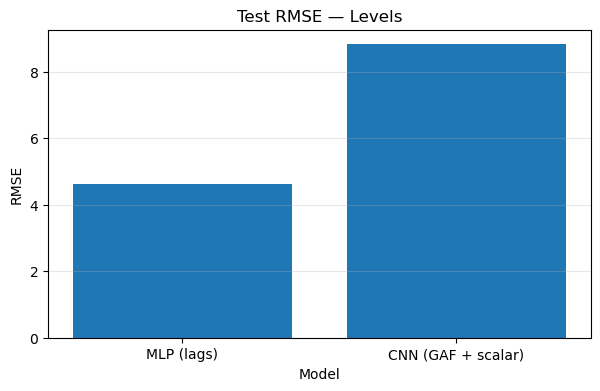

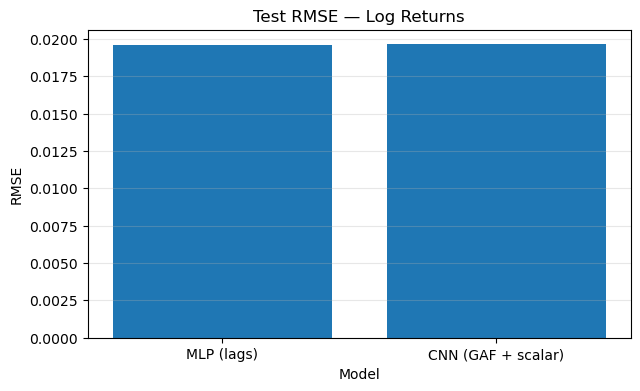

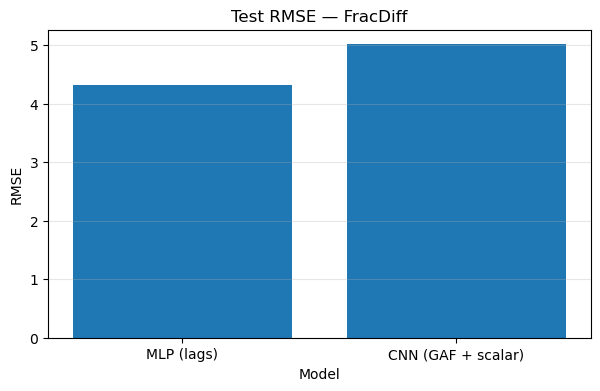

In [118]:
# RMSE bar chart: grouped by representation
reps = compare["Representation"].unique()

for rep in reps:
    sub = compare[compare["Representation"] == rep].copy()
    plt.figure(figsize=(7,4))
    plt.bar(sub["Model"], sub["Test_RMSE"])
    plt.title(f"Test RMSE — {rep}")
    plt.xlabel("Model")
    plt.ylabel("RMSE")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

Plot R² by model for each representation

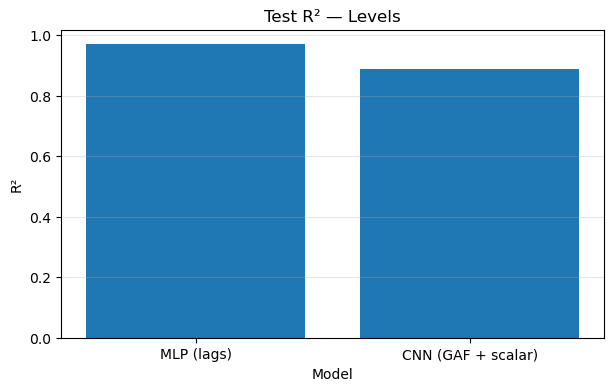

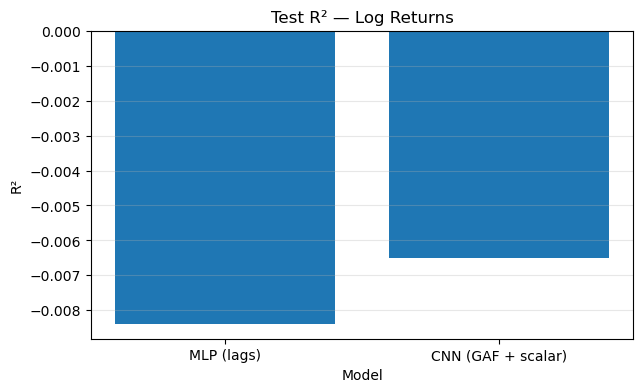

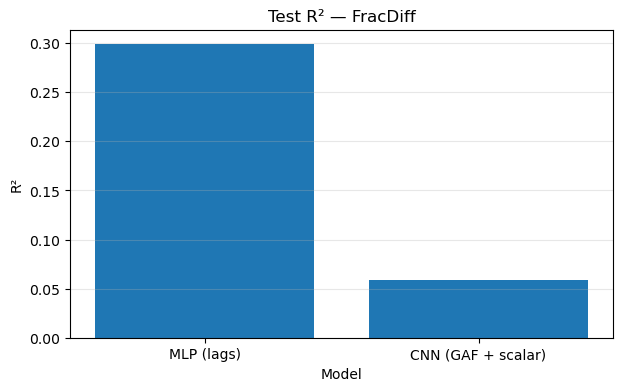

In [119]:
for rep in reps:
    sub = compare[compare["Representation"] == rep].copy()
    plt.figure(figsize=(7,4))
    plt.bar(sub["Model"], sub["Test_R2"])
    plt.title(f"Test R² — {rep}")
    plt.xlabel("Model")
    plt.ylabel("R²")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()